# Analyze city features

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import h3
from shapely.geometry import Polygon, Point
import folium
from branca.colormap import LinearColormap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from tqdm import tqdm
from SPARQLWrapper import SPARQLWrapper, JSON
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import json
from scipy.stats import boxcox
import umap
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors as pc
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from scipy.stats import ranksums
import warnings
import pickle
from scipy import stats
warnings.filterwarnings("ignore")

In [2]:
import matplotlib as mpl
from matplotlib import font_manager
import pathlib

font_dir = pathlib.Path.home() / "fonts"

for f in font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(f))

def setup_mpl():

    mpl.rcParams.update({

        # -------------------
        # Fonts (publication safe)
        # -------------------
        "font.family": "Liberation Sans",
        "font.size": 7,          # base text

        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,

        # keep text editable in SVG/PDF
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # -------------------
        # Lines & axes
        # -------------------
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,

        # -------------------
        # Ticks (Nature style thin & compact)
        # -------------------
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,

        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,

        "xtick.major.pad": 2,
        "ytick.major.pad": 2,

        "xtick.top": False,
        "ytick.right": False,

        # -------------------
        # Layout polish
        # -------------------
        "axes.labelpad": 2,
        "mathtext.default": "regular",
        "legend.frameon": False
    })


setup_mpl()


dict_country = {
    "co":"colombia",
    "mx":"mexico",
    "in":"india",
    "id":"indonesia"
}

dict_titles = {
        "5000":"10 min",
        "7500":"15 min",
        "10000":"20 min",
        "15000":"30 min",
        "22500":"45 min",
        "30000":"1 h",
        "60000":"2 h"
}

def h3_to_polygon(h3_hex):
    # Hex string to polygon
    coords = h3.cell_to_boundary(h3_hex)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)


def get_data(countryID=None):
    countryname = dict_country[countryID]
    case = "pre-covid"
    kind = "empirical"
    df_pre_covid = pd.read_csv("/work/netmob24/data/tmp/" + kind + "_" + case + "_" + countryname + ".csv")
    df_pre_covid["geometry"] = df_pre_covid["cell"].apply(h3_to_polygon)
    gdf_pre_covid = gpd.GeoDataFrame(df_pre_covid, geometry="geometry", crs = "EPSG:4326")
    case = "driving"
    df_driving = pd.read_csv("/work/netmob24/data/tmp/"+ case + "_"+countryname+".csv")
    gdf = pd.merge(gdf_pre_covid, df_driving, on = "cell",how ="inner")
    # Reorganize the data
    gdf = gdf.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
    gdf.rename(columns=dict_titles, inplace=True)
    gdf = pd.melt(gdf, id_vars=['pre-covid', 'pre-covid_cell', 'cell', 'geometry'],
                value_vars=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', "2 h"],
                var_name='threshold', value_name='pre-covid_th')
    return gdf


def bootstrap_median(data, n_bootstrap=1000):
    """
    Calculate the median and its standard error from bootstrap samples.

    Parameters:
    - data: array-like, the dataset from which to sample
    - n_bootstrap: int, the number of bootstrap samples to generate

    Returns:
    - median_estimate: float, the median of the original data
    - se_median: float, the standard error of the median from bootstrap samples
    """
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    medians = np.median(bootstrap_samples, axis=1)
    median_estimate = np.mean(data)
    se_median = np.std(medians)
    return median_estimate, se_median

In [3]:
def get_bins(data=None, col_name=None, weights=None, bin_num=None, weight_lb=True, log_scale=True):
    lower, upper = min(data[col_name]), max(data[col_name])
    if log_scale:
        bins = np.logspace(np.log(lower), np.log(upper), bin_num)
    else:
        bins = np.linspace(lower, upper, bin_num)
    # Use weights in the histogram calculation
    if weight_lb:
        hist, edges = np.histogram(data[col_name], bins=bins, weights=data[weights], density=True)
    else:
        hist, edges = np.histogram(data[col_name], bins=bins, density=True)
    # Normalize to get fractions (relative frequencies)
    #hist_fraction = hist / hist.sum()
    x = (edges[1:] + edges[:-1]) / 2
    
    xx, yy = zip(*[(i, j) for (i, j) in zip(x, hist) if j > 0])
    return data[col_name].median(), xx, yy


def long_tail_distr(data1=None, x_lb=None, y_lb=None, col_name=None, bin_num=50, weights='weight_ind', label=None):
    if weights is not None:
        md_value1, xx1, yy1 = get_bins(data=data1, col_name=col_name, weights=weights, bin_num=bin_num)
    else:
        md_value1, xx1, yy1 = get_bins(data=data1, col_name=col_name, weight_lb=False, bin_num=bin_num)
    fig, ax = plt.subplots()
    ax.plot(xx1, yy1, marker='.', label=label)
    plt.axvline(x=md_value1, color='r', linestyle='dashed', linewidth=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(x_lb)
    ax.set_ylabel(y_lb)
    plt.legend()
    return fig, ax

## 1. Load data and preprocess

In [4]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()
gdf_info = gpd.read_file('/work/netmob24/data/cities/cities_info.geojson')
gdf = pd.merge(gdf, gdf_info.drop(columns=['geometry']), on = "name_city", how = "left")
cities = gdf["correct_name"].unique()
name_to_country = dict(zip(gdf['correct_name'], gdf['country']))
gdf.head()

,cell,component,country,key,name_city,geometry,correct_name,population,area_km2,pop_density
0,8729a4c2affffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93595 32.4931, -116.928 32.5049...",Tijuana,2.954140e+06,547.137308,5399.267006
1,8729a4d51ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.00771 32.43297, -116.99978 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
2,8729a4d59ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.05616 32.47885, -117.04824 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
3,8729a4d08ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93517 32.37582, -116.92723 32.3...",Tijuana,2.954140e+06,547.137308,5399.267006
4,8729a4c65ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.10445 32.50124, -117.09653 32.5...",Tijuana,2.954140e+06,547.137308,5399.267006


In [5]:
# Save cell-city mapping
cell_to_city = dict(zip(gdf['cell'], gdf['correct_name']))
# Save dictionary to a file
with open("../data/cell_to_city.pkl", "wb") as f:
    pickle.dump(cell_to_city, f)

In [6]:
# Columns to aggregate
agg_columns = ['Residential', 'Theoretical', 'Empirical', 'bb_e', 'bb_t', 'bb_g',
               'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini']


def city_agg(x):
    res = dict()
    for var in agg_columns:
        res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(x[var], n_bootstrap=1000)
    return pd.Series(res)


df_cities = []
df_raw = []
for countryID in ("id", "in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Empirical'] - gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Empirical'] - gdf_original.loc[:, 'Theoretical']
    gdf_original = gdf_original[gdf_original['threshold']=='30 min']
    # Load POI data
    df_poi = pd.read_csv(f"../data/pois/pois_{dict_country[countryID]}_cell.csv"
                        , usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    df_raw.append(gdf_original.drop(columns=['geometry']))
    # Group and aggregate
    agg_df = gdf_original.groupby('correct_name')[agg_columns].apply(city_agg).reset_index()

    # Flatten column names
    # agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    agg_df.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(agg_df)
df_cities = pd.concat(df_cities, ignore_index=True)
df_raw = pd.concat(df_raw, ignore_index=True)
df_raw.rename(columns={'country': 'Country'}, inplace=True)
df_cities = pd.merge(df_cities, gdf_info[['correct_name', 'pop_density']], on = ["correct_name"], how = "left")
df_cities.rename(columns={'country': 'Country'}, inplace=True)
df_cities.head()

indonesia
india
mexico


,correct_name,Residential_md,Residential_md_err,Theoretical_md,Theoretical_md_err,Empirical_md,Empirical_md_err,bb_e_md,bb_e_md_err,bb_t_md,...,Number of POI_md,Number of POI_md_err,Number of Unique Categories_md,Number of Unique Categories_md_err,Entropy_md,Entropy_md_err,Gini_md,Gini_md_err,Country,pop_density
0,Bandung,22.432542,1.125935,27.090472,0.847912,20.261152,0.388321,-2.171390,0.633089,4.657930,...,40.955357,2.895523,10.687500,0.710288,2.671751,0.108458,0.775462,0.009250,Indonesia,9012.341974
1,Jarkarta,15.226702,0.190335,16.970607,0.249132,14.808424,0.099170,-0.418279,0.030643,1.743904,...,40.477612,1.448131,11.444030,0.541627,2.786253,0.062182,0.795418,0.005609,Indonesia,10372.323983
2,Karawang,17.562687,0.515543,22.849198,0.446764,15.956978,0.207010,-1.605708,0.473508,5.286512,...,13.241379,3.657797,5.862069,1.406213,1.731413,0.383412,0.744347,0.030312,Indonesia,6821.714134
3,Malang,21.202709,1.285793,28.346545,0.623060,17.825825,0.769090,-3.376884,1.245137,7.143836,...,21.245902,1.424852,8.081967,0.696445,2.342541,0.152139,0.760042,0.021265,Indonesia,7392.233828
4,Semarang,19.261285,1.323630,23.776317,0.655173,16.393129,0.329964,-2.868156,0.814711,4.515031,...,19.287879,1.804328,8.227273,1.263217,2.387389,0.279706,0.760393,0.028128,Indonesia,9073.666314


In [7]:
df_raw.head()

,Empirical,Residential,cell,threshold,Theoretical,Country,correct_name,bb_e,bb_t,bb_g,Number of POI,Number of Unique Categories,Entropy,Gini
0,15.623717,19.898140,878c106d6ffffff,30 min,16.585191,indonesia,Jarkarta,-4.274422,-3.312948,-0.961474,2,2,1.000000,0.500000
1,11.565304,11.140101,878c107a3ffffff,30 min,11.929928,indonesia,Jarkarta,0.425203,0.789827,-0.364624,28,11,2.980167,0.841837
2,14.951609,14.831896,878c100e4ffffff,30 min,21.037899,indonesia,Jarkarta,0.119713,6.206002,-6.086290,88,20,3.813480,0.913223
3,13.881536,13.967230,878c104e8ffffff,30 min,14.018994,indonesia,Jarkarta,-0.085694,0.051764,-0.137459,126,22,3.695647,0.893424
4,10.699677,12.207099,878c10680ffffff,30 min,12.191911,indonesia,Jarkarta,-1.507422,-0.015188,-1.492234,64,17,3.486908,0.879395


### 1.1 Compactness index

In [8]:
gdf = gdf[['cell', 'correct_name', 'country', 'pop_density', 'population', 'geometry']] # pop_density, population are at the city level
df_raw = df_raw[['cell', 'Number of POI']]
gdf = pd.merge(gdf, df_raw, on = "cell", how = "left")
gdf.head()

,cell,correct_name,country,pop_density,population,geometry,Number of POI
0,8729a4c2affffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-116.93595 32.4931, -116.928 32.5049...",140
1,8729a4d51ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.00771 32.43297, -116.99978 32.4...",55
2,8729a4d59ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.05616 32.47885, -117.04824 32.4...",47
3,8729a4d08ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-116.93517 32.37582, -116.92723 32.3...",33
4,8729a4c65ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.10445 32.50124, -117.09653 32.5...",106


In [9]:
def lonlat_to_utm_epsg(lon, lat):
    """Infer UTM EPSG based on centroid lon/lat"""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        return 32600 + zone  # Northern Hemisphere
    else:
        return 32700 + zone  # Southern Hemisphere

def compute_city_compactness_auto_utm(gdf, city_col='city'):
    results = []

    # Ensure input is in WGS84
    gdf = gdf.to_crs("EPSG:4326")

    for city, city_gdf in gdf.groupby(city_col):
        # Compute centroid of all geometries
        centroid = city_gdf.geometry.unary_union.centroid
        lon, lat = centroid.x, centroid.y

        # Determine UTM EPSG
        epsg = lonlat_to_utm_epsg(lon, lat)

        # Project to local UTM CRS
        city_proj = city_gdf.to_crs(epsg=epsg)

        # Union of hexagons for this city
        geom_union = city_proj.geometry.unary_union

        # Compute area and perimeter
        area = geom_union.area
        perimeter = geom_union.length

        # Compactness
        compactness = (4 * np.pi * area) / (perimeter ** 2)

        results.append({
            city_col: city,
            'epsg': epsg,
            'area_m2': area,
            'perimeter_m': perimeter,
            'compactness': compactness
        })

    return gpd.GeoDataFrame(results)

df_metrics = compute_city_compactness_auto_utm(gdf, city_col='correct_name')
df_metrics = pd.merge(df_metrics[['correct_name', 'compactness']], 
                      gdf[['correct_name', 'country', 'pop_density', 'population']].drop_duplicates(subset=['correct_name']), 
                      left_on='correct_name', right_on='correct_name', how='left')
print(df_metrics.sort_values('compactness'))

           correct_name  compactness    country   pop_density    population
19  Greater Mexico City     0.066986     mexico   8012.457375  2.441359e+07
61                Thane     0.075048      india   8226.689316  7.550907e+06
58             Surabaya     0.094591  indonesia   9644.430213  7.132354e+06
64               Toluca     0.107505     mexico   5655.007157  4.613274e+06
28             Jarkarta     0.110554  indonesia  10372.323983  2.893304e+07
..                  ...          ...        ...           ...           ...
60                Surat     0.456249      india   9599.918766  2.225860e+06
62   Thiruvananthapuram     0.517309      india   9575.655485  1.404989e+06
67             Vadodara     0.540394      india  10247.025102  1.707211e+06
35             Ludhiana     0.572110      india  12230.728948  2.314525e+06
37            Matamoros     0.588317     mexico   6315.071977  9.766193e+05

[72 rows x 5 columns]


### 1.2 Get cell-level population count

In [10]:
# Replace 'your_file.json' with your file path
with open('../data/population/population.json', 'r', encoding='utf-8') as f:
    pop_cell_dict = json.load(f)

In [11]:
gdf.loc[:, 'pop'] = gdf['cell'].map(pop_cell_dict)
gdf.loc[:, 'poi_capita'] = gdf['Number of POI'] / (gdf['pop'] / 1000)  # no. of POI per 1000 inhabitants
# Drop rows where poi_capita is inf or -inf
gdf = gdf[np.isfinite(gdf['poi_capita'])].copy()
gdf.head()

,cell,correct_name,country,pop_density,population,geometry,Number of POI,pop,poi_capita
0,8729a4c2affffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-116.93595 32.4931, -116.928 32.5049...",140,46269.888889,3.025726
1,8729a4d51ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.00771 32.43297, -116.99978 32.4...",55,27717.900000,1.984277
2,8729a4d59ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.05616 32.47885, -117.04824 32.4...",47,41759.950000,1.125480
3,8729a4d08ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-116.93517 32.37582, -116.92723 32.3...",33,16089.600000,2.051014
4,8729a4c65ffffff,Tijuana,mexico,5399.267006,2.954140e+06,"POLYGON ((-117.10445 32.50124, -117.09653 32.5...",106,40487.822222,2.618071


In [12]:
def poi_metrics(data):
    md, se = bootstrap_median(data['poi_capita'], n_bootstrap=1000)   # no. of POI per 1000 inhabitants
    return pd.Series({'poi_capita_md': md, 'poi_capita_se': se})

df_poi_metrics = gdf.groupby('correct_name').apply(poi_metrics).reset_index()
df_poi_metrics.head(10)

,correct_name,poi_capita_md,poi_capita_se
0,Acapulco,0.834249,0.104670
1,Aguascalientes,1.725366,0.143224
2,Ahmadabad,1.177189,0.108853
3,Altamira,1.712003,0.195972
4,Bandung,0.721011,0.036502
5,Bangalore,0.904828,0.054968
6,Bhopal,0.574915,0.074101
7,Bhubaneswar,0.981948,0.170291
8,Cabo San Lucas,1.637969,0.207459
9,Cancún,2.468349,0.338363


### 1.3 Put together metrics

In [13]:
df_metrics = pd.merge(df_metrics, df_poi_metrics, on='correct_name', how='left')
df_metrics.head(10)

,correct_name,compactness,country,pop_density,population,poi_capita_md,poi_capita_se
0,Acapulco,0.253746,mexico,6563.125736,1.465035e+06,0.834249,0.104670
1,Aguascalientes,0.388311,mexico,7074.440689,1.728564e+06,1.725366,0.143224
2,Ahmadabad,0.434624,india,11916.459803,4.675171e+06,1.177189,0.108853
3,Altamira,0.259894,mexico,5941.831883,1.377988e+06,1.712003,0.195972
4,Bandung,0.153939,indonesia,9012.341974,5.159743e+06,0.721011,0.036502
5,Bangalore,0.264204,india,10484.785021,8.831870e+06,0.904828,0.054968
6,Bhopal,0.417566,india,8302.054387,1.755856e+06,0.574915,0.074101
7,Bhubaneswar,0.365323,india,6275.345325,9.915830e+05,0.981948,0.170291
8,Cabo San Lucas,0.142754,mexico,2776.807917,7.230714e+05,1.637969,0.207459
9,Cancún,0.158729,mexico,6007.221056,1.455824e+06,2.468349,0.338363


### 1.4 Prepare overall data (descriptive)
30 min threshold in gravity.

In [14]:
# Columns to aggregate
agg_columns = ['Residential', 'Theoretical', 'Empirical', 'bb_e', 'bb_t', 'bb_g',
               'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini']

df_cities = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] =  gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']
    # Load POI data
    df_poi = pd.read_csv(f"../data/pois/pois_{dict_country[countryID]}_cell.csv"
                        , usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    gdf_original.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(gdf_original)
    
df_cities = pd.concat(df_cities, ignore_index=True)
df_cities.columns = ['Empirical', 'Residential', 'cell', 'geometry', 'threshold',
       'Theoretical', 'country', 'correct_name', 'bb_e', 'bb_t', 'bb_g',
       'no_poi', 'no_poi_cat', 'poi_entropy', 'poi_gini']
df_cities = df_cities[df_cities['threshold'] == "45 min"]
df_cities = df_cities.merge(gdf[['cell', 'poi_capita']], on='cell', how='left')
df_cities.head()

india
mexico


,Empirical,Residential,cell,geometry,threshold,Theoretical,country,correct_name,bb_e,bb_t,bb_g,no_poi,no_poi_cat,poi_entropy,poi_gini,poi_capita
0,24.306035,24.073137,873c13164ffffff,"POLYGON ((85.16066 25.57624, 85.15653 25.58821...",45 min,25.905866,India,Patna,-0.232898,-1.832729,1.599831,47,20,3.990210,0.924400,0.716892
1,24.503374,24.073137,873c13165ffffff,"POLYGON ((85.18447 25.58366, 85.18034 25.59564...",45 min,25.029396,India,Patna,-0.430237,-0.956259,0.526022,37,16,3.644152,0.899927,0.561257
2,25.358434,25.304953,873c138c8ffffff,"POLYGON ((85.14827 25.61214, 85.14414 25.62411...",45 min,25.464984,India,Patna,-0.053481,-0.160031,0.106550,204,29,4.146882,0.922097,3.516090
3,25.268785,26.228815,873c138c9ffffff,"POLYGON ((85.17208 25.61957, 85.16795 25.63154...",45 min,26.067164,India,Patna,0.960030,0.161651,0.798378,56,19,3.618298,0.889031,1.389255
4,24.768184,24.073137,873c138caffffff,"POLYGON ((85.14257 25.59048, 85.13843 25.60245...",45 min,24.227776,India,Patna,-0.695047,-0.154639,-0.540408,136,20,3.546374,0.878460,2.025685


## 2. Cluster cities - compactness

In [15]:
def assign_compactness_cluster_within_country(group):
    median_c = group['compactness'].median()
    def cluster(row):
        if row['compactness'] <= median_c:
            return 1
        elif row['compactness'] > median_c:
            return 2

    group['Cluster'] = group.apply(cluster, axis=1)
    return group

df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)

cluster_name_dict = {
    2: "Compact",
    1: "Sparse",
}
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].map(cluster_name_dict)

In [16]:
df_cities = df_cities.merge(df_metrics_c[['correct_name', 'Cluster_c', 'compactness']], on='correct_name', how='left')

In [17]:
# Aggregate by country
summary_compactness = (
    df_metrics_c
    .groupby('country')['compactness']
    .agg(
        Median='median',
        P5=lambda x: x.quantile(0.05),
        P95=lambda x: x.quantile(0.95)
    )
    .reset_index()
    .round(3)
)

print(summary_compactness)

     country  Median     P5    P95
0      india   0.348  0.142  0.535
1  indonesia   0.181  0.100  0.341
2     mexico   0.269  0.125  0.428


### 2.1 Compactness vs. bbg

In [18]:
df_cities.head()

,Empirical,Residential,cell,geometry,threshold,Theoretical,country,correct_name,bb_e,bb_t,bb_g,no_poi,no_poi_cat,poi_entropy,poi_gini,poi_capita,Cluster_c,compactness
0,24.306035,24.073137,873c13164ffffff,"POLYGON ((85.16066 25.57624, 85.15653 25.58821...",45 min,25.905866,India,Patna,-0.232898,-1.832729,1.599831,47,20,3.990210,0.924400,0.716892,Compact,0.41508
1,24.503374,24.073137,873c13165ffffff,"POLYGON ((85.18447 25.58366, 85.18034 25.59564...",45 min,25.029396,India,Patna,-0.430237,-0.956259,0.526022,37,16,3.644152,0.899927,0.561257,Compact,0.41508
2,25.358434,25.304953,873c138c8ffffff,"POLYGON ((85.14827 25.61214, 85.14414 25.62411...",45 min,25.464984,India,Patna,-0.053481,-0.160031,0.106550,204,29,4.146882,0.922097,3.516090,Compact,0.41508
3,25.268785,26.228815,873c138c9ffffff,"POLYGON ((85.17208 25.61957, 85.16795 25.63154...",45 min,26.067164,India,Patna,0.960030,0.161651,0.798378,56,19,3.618298,0.889031,1.389255,Compact,0.41508
4,24.768184,24.073137,873c138caffffff,"POLYGON ((85.14257 25.59048, 85.13843 25.60245...",45 min,24.227776,India,Patna,-0.695047,-0.154639,-0.540408,136,20,3.546374,0.878460,2.025685,Compact,0.41508


In [19]:
for country in ['India', 'Mexico']:
    print(country)
    compact = df_cities.loc[(df_cities['Cluster_c'] == 'Compact') & (df_cities['country'] == country), 'bb_g']
    sparse  = df_cities.loc[(df_cities['Cluster_c'] == 'Sparse') & (df_cities['country'] == country),  'bb_g']
    u_stat, p_val = stats.mannwhitneyu(compact, sparse, alternative='greater')
    print(f"U={u_stat:.3f}, p={p_val:.4f}")
    cohen_d = (compact.mean() - sparse.mean()) / np.sqrt((compact.var() + sparse.var()) / 2)
    print(f"Cohen's d: {cohen_d:.2f}")

India
U=411111.000, p=0.0000
Cohen's d: 0.28
Mexico
U=799873.000, p=0.0000
Cohen's d: 0.18


### Visualize two example cities
This is to show the compactness.

In [28]:
df_top = df_cities[df_cities["correct_name"].isin(["Tijuana", 'Ludhiana'])].copy()

def plot_two_cities(
    df_top,
    city_names,
    title_names=None,
    zoom=12,
    figsize_mm=90,
    pad_m=1000,
    alpha=0.7,
    savepath=None,
):
    if len(city_names) != 2:
        raise ValueError("city_names must contain exactly two city names.")

    gdf = df_top.to_crs(epsg=3857).copy()

    # Titles
    if title_names is None:
        title_names = list(city_names)
    if len(title_names) != 2:
        raise ValueError("title_names must be length 2 (or None).")

    # Filter + sanity check
    gdfs = []
    for name in city_names:
        g = gdf[gdf["correct_name"] == name]
        if g.empty:
            available = sorted(gdf["correct_name"].dropna().unique())
            raise ValueError(
                f"City '{name}' not found in df_top['correct_name']. "
                f"Example available names: {available[:10]}"
            )
        gdfs.append(g)

    # Figure size: choose a clean aspect (2 panels)
    fig_w_in = (figsize_mm * 0.55 / 25.4)  # looks good for 2 panels
    fig_h_in = (figsize_mm / 25.4)
    fig, axes = plt.subplots(2, 1, figsize=(fig_w_in, fig_h_in))
    axes = np.array(axes).reshape(2,)

    for ax, g_city, title in zip(axes, gdfs, title_names):

        # ---- square extent around city ----
        xmin, ymin, xmax, ymax = g_city.total_bounds
        xmin, ymin, xmax, ymax = xmin - pad_m, ymin - pad_m, xmax + pad_m, ymax + pad_m
        w, h = (xmax - xmin), (ymax - ymin)
        if w > h:
            d = (w - h) / 2
            ymin -= d
            ymax += d
        else:
            d = (h - w) / 2
            xmin -= d
            xmax += d

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", "box")

        # ---- overlay ----
        g_city.plot(
            ax=ax,
            color='steelblue',
            edgecolor="white",
            alpha=alpha,
            zorder=3
        )

        # ---- clean axes ----
        #ax.set_title(title)
        ax.axis("off")

    if savepath:
        plt.tight_layout()
        fig.savefig(savepath, dpi=600, facecolor="white")
        print(f"✅ Saved to: {savepath}")

    return fig, axes

✅ Saved to: ../figures/illustration_compactness.png


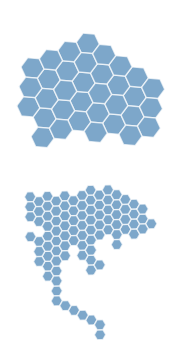

In [29]:
fig, axes = plot_two_cities(
    df_top,
    city_names=['Ludhiana', "Tijuana"],
    title_names=['Compact\n(Ludhiana, India)', "Sparse\n(Tijuana, Mexico)"],
    savepath="../figures/illustration_compactness.png"
)
plt.show()

<Axes: >

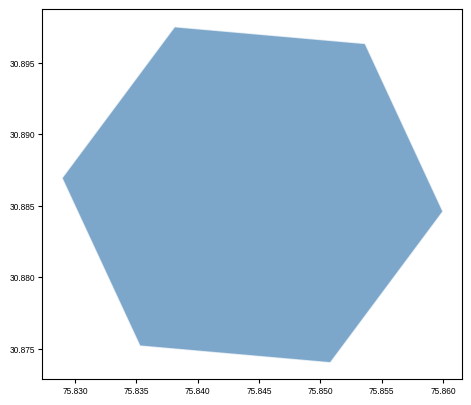

In [31]:
df_top[:1].plot(
            color='steelblue',
            edgecolor="white",
            zorder=3, alpha=0.7
        )

#### Select comparable compact and sparse cities
Control for residential deprivation and number of cells in the city.

In [20]:
# Group by country and compute mean compactness per city
city_compactness = (
    df_cities.groupby(["country", "correct_name"], as_index=False)["compactness"]
    .mean()
)

# For each country, get top 5 and bottom 5 cities
top_bottom_cities = (
    city_compactness.groupby("country", group_keys=False)
    .apply(lambda x: pd.concat([
        x.nlargest(5, "compactness"),
        x.nsmallest(5, "compactness")
    ]))
    .reset_index(drop=True)
)

# Now filter df_cities to only include those selected cities
df_subset = df_cities[df_cities["correct_name"].isin(top_bottom_cities["correct_name"])].copy()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
agg_vars = ['n_cells', 'Residential']
# Compute mean, weighted by number of cells (if relevant)
df_subset['cell_weight'] = 1  # each cell counts equally unless you have other weights

# Step 1: Summarize cities
city_summary = (
    df_subset
    .groupby(['country', 'correct_name', 'Cluster_c'])
    .apply(lambda g: pd.Series({
        'n_cells': len(g),
        'Residential': np.average(g['Residential'], weights=g['cell_weight']),
    }))
    .reset_index()
)

pairs = []

# Step 2: Loop over each country
for country, group in city_summary.groupby('country'):
    compact = group[group['Cluster_c'] == 'Compact'].copy()
    sparse  = group[group['Cluster_c'] == 'Sparse'].copy()

    # Skip if we don't have at least 2 of each type
    if len(compact) < 2 or len(sparse) < 2:
        continue

    # Standardize within country
    scaler = StandardScaler()
    X_compact = scaler.fit_transform(compact[agg_vars])
    X_sparse  = scaler.transform(sparse[agg_vars])

    dist_matrix = euclidean_distances(X_compact, X_sparse)

    # Track used compact/sparse indices
    used_compact = set()
    used_sparse = set()

    # Greedy matching for 2 distinct pairs
    for _ in range(2):
        best_i, best_j = None, None
        best_dist = np.inf

        for i in range(len(compact)):
            if i in used_compact:
                continue
            for j in range(len(sparse)):
                if j in used_sparse:
                    continue
                dist = dist_matrix[i, j]
                if dist < best_dist:
                    best_i, best_j = i, j
                    best_dist = dist

        if best_i is not None and best_j is not None:
            used_compact.add(best_i)
            used_sparse.add(best_j)
            pairs.append({
                'country': country,
                'compact_city': compact.iloc[best_i]['correct_name'],
                'sparse_city': sparse.iloc[best_j]['correct_name'],
                'distance': best_dist
            })

# Step 3: Final selection
matched_pairs = pd.DataFrame(pairs)

selected_names = pd.unique(
    matched_pairs[['compact_city', 'sparse_city']].values.ravel()
)
df_top = df_subset[df_subset['correct_name'].isin(selected_names)]

In [22]:
df_top['correct_name'].unique()

array(['Chennai', 'Visakhapatnam', 'Kanpur', 'Surat', 'Toluca', 'León',
       'Puebla', 'Cuernavaca'], dtype=object)

#### Visualize on the map

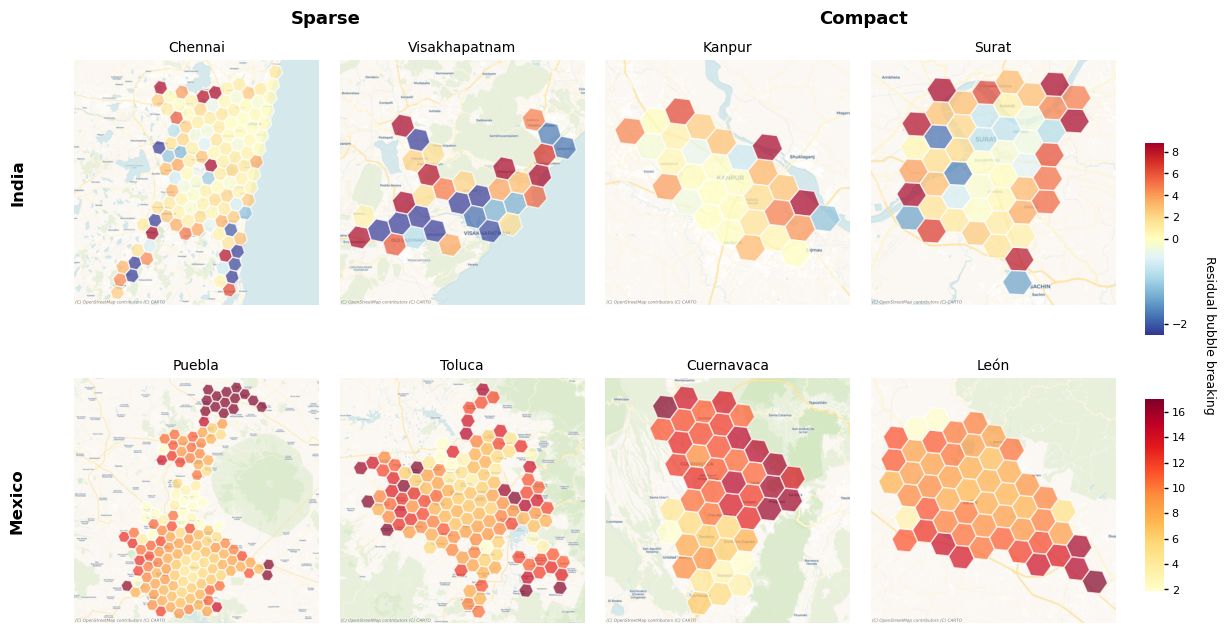

In [23]:
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import geopandas as gpd
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

# --- Ensure geometry and CRS ---
df_top = df_top.to_crs(epsg=3857)
df_top = df_top.sort_values(["country", "Cluster_c", "correct_name"])

countries = df_top["country"].unique()
n_countries = len(countries)

# 4 columns → 2 for Sparse, 2 for Compact
ncols = 4
nrows = n_countries

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(3.2*4, 3.2*2), # 4 * ncols, 4 * nrows
    subplot_kw={'aspect': 'equal'}   # (3) maintain square axes
)
axes = np.array(axes).reshape(nrows, ncols)

# --- Loop by country ---
for row_i, country in enumerate(countries):
    df_country = df_top[df_top["country"] == country]
    vmin, vmax = df_country["bb_g"].quantile([0.05, 0.95])

    # Diverging normalization for India, sequential otherwise
    if country == "India":
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        cmap = "RdYlBu_r"
    else:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = "YlOrRd"

    # Compact & Sparse groups
    city_groups = (
        df_country.groupby("Cluster_c")["correct_name"]
        .unique()
        .to_dict()
    )

    # Plot each city
    for col_i, cluster_type in enumerate(["Sparse", "Compact"]):
        cities = city_groups.get(cluster_type, [])
        for j, city in enumerate(cities[:2]):  # only top 2 each
            col_index = col_i * 2 + j
            if col_index >= 4:
                continue

            ax = axes[row_i, col_index]
            gdf_city = df_country[df_country["correct_name"] == city]

            # Compute square bounding box extent
            xmin, ymin, xmax, ymax = gdf_city.total_bounds
            xmin, ymin, xmax, ymax = xmin-1000, ymin-1000, xmax+1000, ymax+1000
            width = xmax - xmin
            height = ymax - ymin
            if width > height:
                diff = (width - height) / 2
                ymin -= diff
                ymax += diff
            else:
                diff = (height - width) / 2
                xmin -= diff
                xmax += diff
            extent = (xmin, xmax, ymin, ymax)

            # Plot
            gdf_city.plot(
                ax=ax,
                column="bb_g",
                cmap=cmap,
                norm=norm,
                edgecolor="white",
                alpha=0.7,
            )

            # Force all maps to square extent
            ax.set_xlim(extent[0], extent[1])
            ax.set_ylim(extent[2], extent[3])
            ax.set_aspect("equal", "box")  # ensure visual square

            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=12)
            # Find and adjust the attribution text
            for artist in ax.texts:
                if "OpenStreetMap" in artist.get_text():
                    artist.set_fontsize(3)       # smaller font
                    artist.set_alpha(0.3)        # optional: make it lighter
                    artist.set_fontstyle('italic')
            ax.set_title(f"{city}", fontsize=10)
            ax.axis("off")

    # (1) Add country label on the left
    axes[row_i, 0].annotate(
        country,
        xy=(-0.2, 0.5),
        xycoords="axes fraction",
        va="center",
        ha="right",
        fontsize=12,
        fontweight="bold",
        rotation=90
    )

    # (2) Colorbar on the right of the row
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    # Add axis to the right of this row
    cbar_ax = fig.add_axes([
        0.92,                          # x-position (right side)
        0.1 + (n_countries - row_i - 1) * (0.8 / n_countries),  # y-position per row
        0.015,                         # width
        0.6 / n_countries              # height
    ])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cbar.set_label("", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_visible(False)  # ← removes the black border

# (1b) Add centered column headers for Sparse / Compact
fig.text(0.28, 0.98, "Sparse", ha="center", va="bottom", fontsize=13, fontweight="bold")
fig.text(0.7, 0.98, "Compact", ha="center", va="bottom", fontsize=13, fontweight="bold")
fig.text(
    0.97, 0.5,  # move near the right edge, vertically centered
    "Residual bubble breaking",
    ha="center", va="center",
    rotation=270,             # 270° = counterclockwise vertical
    fontsize=9
)
# Adjust layout
plt.subplots_adjust(
    left=0.08, right=0.90, top=0.93, bottom=0.05,
    hspace=0.3, wspace=0.05
)
fig.savefig(f"../figures/bbg_vs_urban_form.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
def plot_bbg_country_comparison(
    df,
    value_col="bb_g",
    cluster_col="Cluster_c",
    country_col="country",
    countries=("India", "Mexico"),
    colors={"Compact": "#ff6b6b", "Sparse": "#1e90ff"},
    savepath=None
):
    """
    Compare reverse cumulative (1-CDF) distributions of bb_g
    between Compact vs Sparse within two countries.
    Produces side-by-side plots for India and Mexico.
    """
    fig, axes = plt.subplots(2, 1, figsize=(3.2, 3.2*2), dpi=300, sharey=True)

    for ax, country in zip(axes, countries):
        df_c = df[df[country_col] == country].copy()

        for cluster_type, color in colors.items():
            subset = df_c[df_c[cluster_col] == cluster_type]
            data = np.sort(subset[value_col].dropna())
            if len(data) == 0:
                continue
            cdf = np.arange(1, len(data) + 1) / len(data)
            rev_cdf = 1 - cdf

            ax.plot(
                data,
                rev_cdf,
                color=color,
                lw=1.3,
                label=cluster_type
            )

            # --- Add horizontal line at x=0 intersection ---
            y_intersect = 1 - (np.searchsorted(data, 0, side="right") / len(data))
            ax.axhline(y_intersect, color=color, lw=0.8, ls="--", alpha=0.5)
            ax.text(
                ax.get_xlim()[0], y_intersect + 0.02,
                f"{y_intersect*100:.1f}%",
                color=color, fontsize=6, va="bottom"
            )

        # --- Axis formatting ---
        ax.axvline(0, color="black", lw=0.4, ls="--", alpha=0.4)
        ax.set_title(country, fontsize=9, loc="left", fontweight="bold")
        ax.set_xlabel("Residual bubble breaking")
        if ax == axes[0]:
            ax.set_ylabel("Fraction of cells > x")
        else:
            ax.set_ylabel("")
        ax.set_ylim(0, 1)
        ax.legend(frameon=False, fontsize=7, loc="lower right")
        sns.despine(ax=ax)

    plt.tight_layout()

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"✅ Figure saved to: {savepath}")
    else:
        plt.show()

    return fig, axes

✅ Figure saved to: ../figures/bbg_vs_urban_form_distr.png


(<Figure size 960x1920 with 2 Axes>,
 array([<Axes: title={'left': 'India'}, xlabel='Residual bubble breaking', ylabel='Fraction of cells > x'>,
        <Axes: title={'left': 'Mexico'}, xlabel='Residual bubble breaking'>],
       dtype=object))

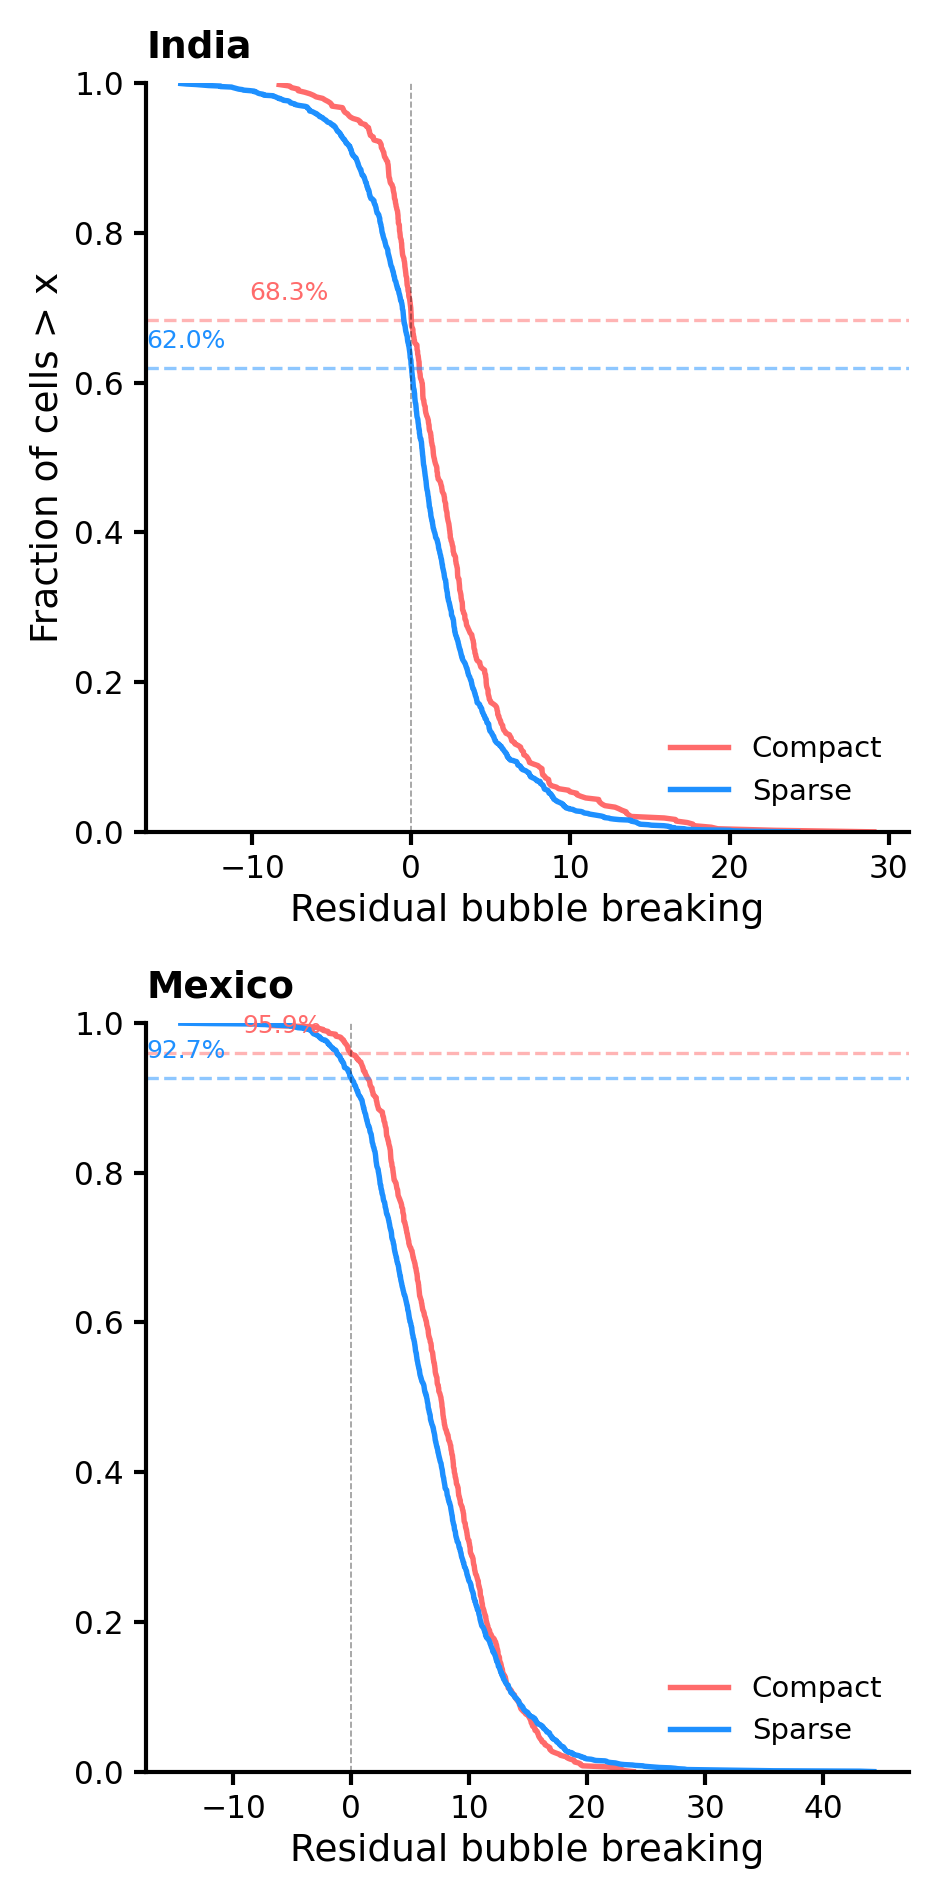

In [29]:
plot_bbg_country_comparison(
    df_cities,
    value_col="bb_g",
    cluster_col="Cluster_c",
    country_col="country",
    countries=("India", "Mexico"),
    colors={"Compact": "#ff6b6b", "Sparse": "#1e90ff"},
    savepath="../figures/bbg_vs_urban_form_distr.png"
)

## 3. Cluster cities (binning approach within each country)

In [13]:
def assign_cluster_within_country(group):
    median_c = group['compactness'].median()
    median_p = group['poi_capita_md'].median()

    def cluster(row):
        if row['compactness'] <= median_c and row['poi_capita_md'] <= median_p:
            return 1
        elif row['compactness'] <= median_c and row['poi_capita_md'] > median_p:
            return 2
        elif row['compactness'] > median_c and row['poi_capita_md'] <= median_p:
            return 3
        else:
            return 4

    group['Cluster'] = group.apply(cluster, axis=1)
    return group

df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_cluster_within_country)

cluster_name_dict = {
    3: "Compact & Amenity-poor cities",
    2: "Sparse & Amenity-rich cities",
    1: "Sparse & Amenity-poor cities",
    4: "Compact & Amenity-rich cities"
}
df_metrics_c['Cluster'] = df_metrics_c['Cluster'].map(cluster_name_dict)
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].apply(lambda x: x.split('&')[0].strip())
df_metrics_c['Cluster_a'] = df_metrics_c['Cluster'].apply(lambda x: x.split('&')[1].strip().split(' ')[0])

In [14]:
df_metrics_c.head()

,correct_name,compactness,country,pop_density,population,poi_capita_md,poi_capita_se,Cluster,Cluster_c,Cluster_a
0,Acapulco,0.253746,mexico,6563.125736,1.465035e+06,0.834249,0.101552,Sparse & Amenity-poor cities,Sparse,Amenity-poor
1,Aguascalientes,0.388311,mexico,7074.440689,1.728564e+06,1.725366,0.139300,Compact & Amenity-rich cities,Compact,Amenity-rich
2,Ahmadabad,0.434624,india,11916.459803,4.675171e+06,1.177189,0.109600,Compact & Amenity-rich cities,Compact,Amenity-rich
3,Altamira,0.259894,mexico,5941.831883,1.377988e+06,1.712003,0.185609,Sparse & Amenity-rich cities,Sparse,Amenity-rich
4,Bandung,0.153939,indonesia,9012.341974,5.159743e+06,0.721011,0.038142,Sparse & Amenity-rich cities,Sparse,Amenity-rich


In [16]:
df_metrics_c.to_csv('../data/cities/cities_cluster.csv', index=False)

## 4. Visualize the clusters

In [15]:
print(df_metrics_c.groupby(['country', 'Cluster'])[['compactness', 'poi_capita_md']].median().reset_index())

      country                        Cluster  compactness  poi_capita_md
0       india  Compact & Amenity-poor cities     0.419379       0.710072
1       india  Compact & Amenity-rich cities     0.408214       1.112898
2       india   Sparse & Amenity-poor cities     0.250018       0.755428
3       india   Sparse & Amenity-rich cities     0.194378       1.220445
4   indonesia  Compact & Amenity-poor cities     0.237444       0.371098
5   indonesia  Compact & Amenity-rich cities     0.267705       0.634221
6   indonesia   Sparse & Amenity-poor cities     0.094591       0.384530
7   indonesia   Sparse & Amenity-rich cities     0.153939       0.639811
8      mexico  Compact & Amenity-poor cities     0.401108       1.379097
9      mexico  Compact & Amenity-rich cities     0.343492       1.835182
10     mexico   Sparse & Amenity-poor cities     0.235277       1.070897
11     mexico   Sparse & Amenity-rich cities     0.158729       1.743456


In [16]:
df_metrics_c['country'] = df_metrics_c['country'].apply(lambda x: x.capitalize())
df_metrics_c['correct_name'] = df_metrics_c['correct_name'].apply(lambda x: 'Guadalajara MA' if x == 'Guadalajara Metropolitan Area' else x)

In [17]:
# Drop indonesia due to lack of data
df_metrics_c = df_metrics_c[df_metrics_c['country'] != 'Indonesia'].copy()

### Amenity richness category

In [ ]:
# Derive urban form (Compact or Sparse) for coloring
df_metrics_c['Amenity context'] = df_metrics_c['Cluster_a'].apply(lambda x: 'Rich' if 'Amenity-rich' in x else 'Poor')

# Sort within each country by poi_capita_md descending
df_sorted = df_metrics_c.sort_values(by=['country', 'poi_capita_md'], ascending=[True, False])

# Assign sorted order index for plotting
df_sorted['x_pos'] = range(len(df_sorted))

# Color palettes
urban_palette = {'Rich': '#1f77b4', 'Poor': '#ff7f0e'}
country_palette = {'Mexico': '#D62728', 'India': '#2CA02C', 'Indonesia': '#9467BD'}

# Plot
fig = plt.figure(figsize=(12, 4),dpi = 300)
ax = fig.add_subplot(1,1,1)
sns.scatterplot(
    data=df_sorted,
    x='x_pos',
    y='poi_capita_md',
    hue='Amenity context',
    palette=urban_palette,
    s=30,
    alpha=0.9
)

# Add error bars
for _, row in df_sorted.iterrows():
    plt.errorbar(
        x=row['x_pos'],
        y=row['poi_capita_md'],
        yerr=row['poi_capita_se'],
        fmt='none',
        ecolor=urban_palette[row['Amenity context']],
        capsize=4,
        alpha=0.8
    )
sns.despine(ax=ax)

# Set custom x-tick labels
ax = plt.gca()
ax.set_xticks(df_sorted['x_pos'])
ax.set_xticklabels(df_sorted['correct_name'], rotation=45, ha='right')

# === Add brackets under x-axis === #
# Group by country and get index ranges
country_ranges = df_sorted.groupby('country')['x_pos'].agg(['min', 'max']).reset_index()

for _, row in country_ranges.iterrows():
    xmin, xmax = row['min'], row['max']
    country = row['country']
    y = -0.5  # offset below x-axis (in axis coordinates)

    # Draw horizontal line (bracket)
    ax.plot([xmin, xmax], [y, y], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)

    # Draw vertical ticks on bracket ends
    ax.plot([xmin, xmin], [y, y + 0.02], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)
    ax.plot([xmax, xmax], [y, y + 0.02], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)

    # Add country label centered below bracket
    ax.text((xmin + xmax) / 2, y - 0.01, country, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=10)

# Add country legend manually
custom_lines = [Line2D([0], [0], color=country_palette[c], lw=4) for c in country_palette]
plt.ylabel('No. of POIs per 1000 inhabitants')
plt.xlabel('')
# plt.title('POIs per Capita by City, Country, and Urban Form')

# Legend: Amenity context (automatically created by seaborn)
ax.legend(
    title='Amenity context',
    frameon=False,
    loc='upper right'
)
plt.tight_layout()
fig.savefig(f"../figures/amenity_context.png", dpi=300, bbox_inches='tight')
plt.show()

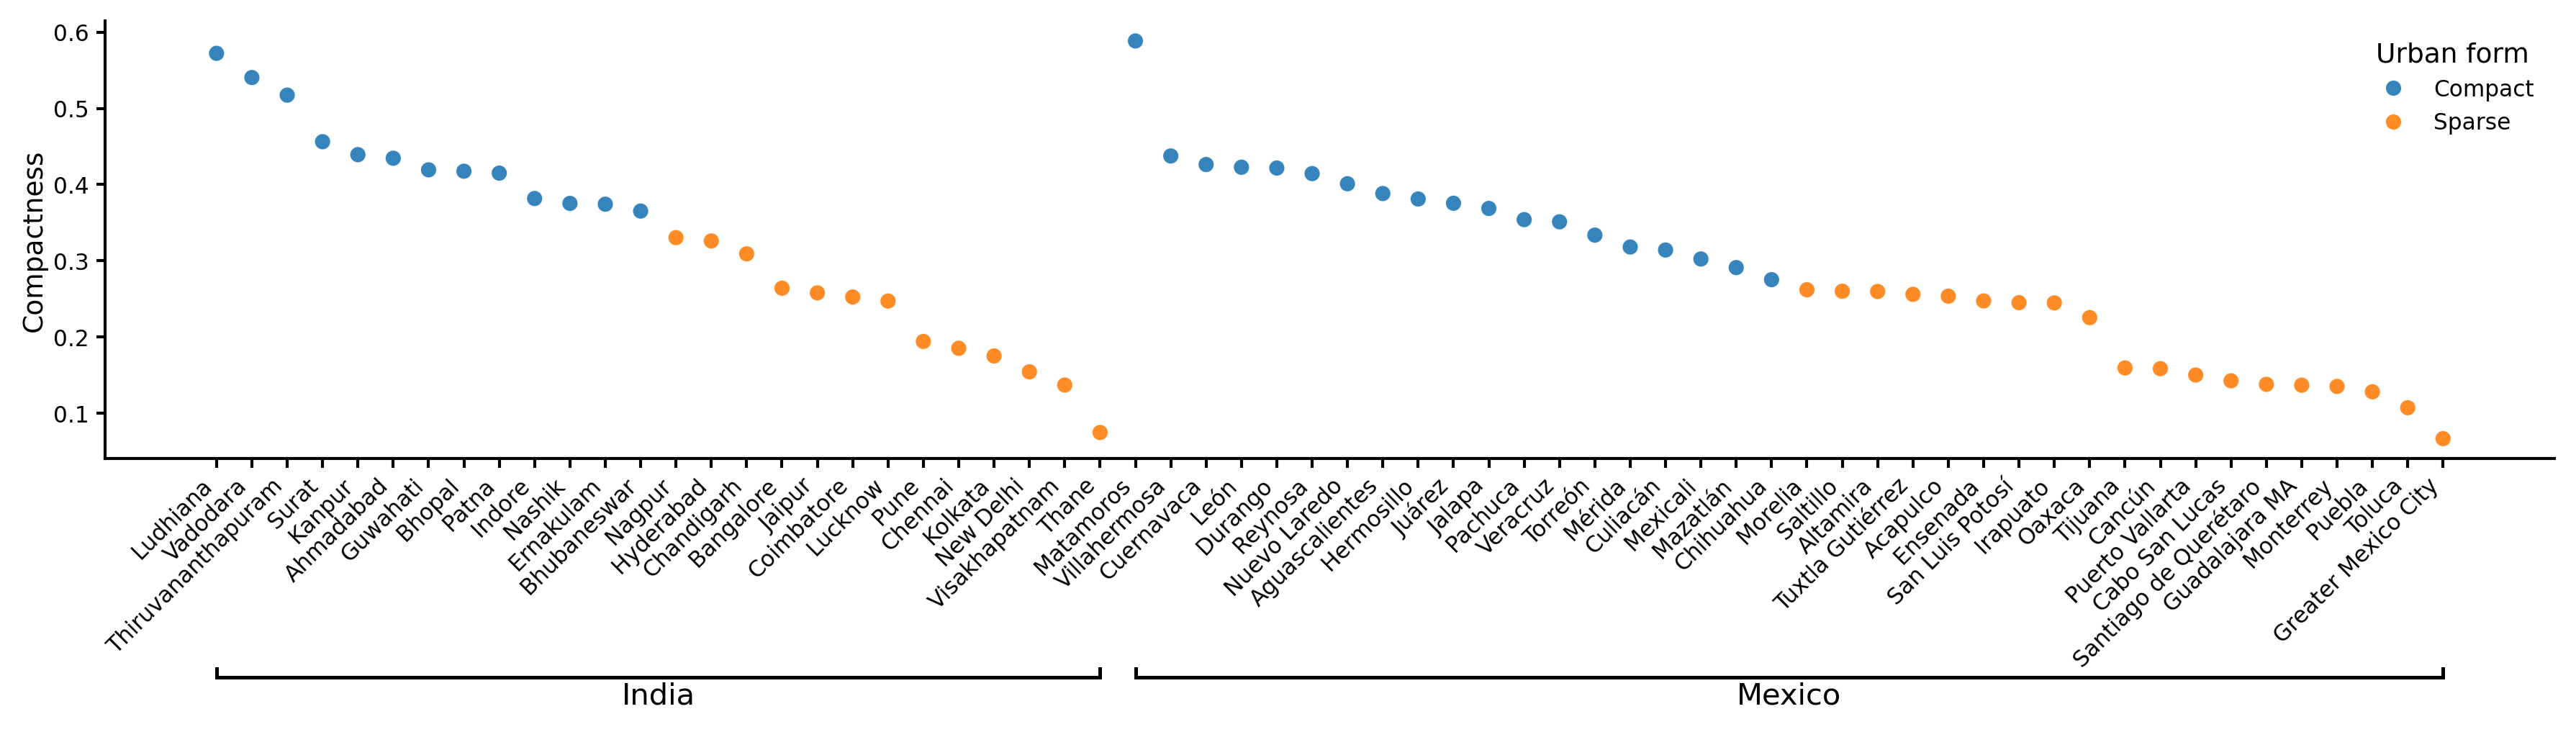

In [21]:
# Derive urban form (Compact or Sparse) for coloring
df_metrics_c['Urban form'] = df_metrics_c['Cluster_c']

# Sort within each country by poi_capita_md descending
df_sorted = df_metrics_c.sort_values(by=['country', 'compactness'], ascending=[True, False])

# Assign sorted order index for plotting
df_sorted['x_pos'] = range(len(df_sorted))

# Color palettes
urban_palette = {'Compact': '#1f77b4', 'Sparse': '#ff7f0e'}

# Plot
fig = plt.figure(figsize=(12, 4),dpi = 300)
ax = fig.add_subplot(1,1,1)
sns.scatterplot(
    data=df_sorted,
    x='x_pos',
    y='compactness',
    hue='Urban form',
    palette=urban_palette,
    s=30,
    alpha=0.9
)
sns.despine(ax=ax)

# Set custom x-tick labels
ax = plt.gca()
ax.set_xticks(df_sorted['x_pos'])
ax.set_xticklabels(df_sorted['correct_name'], rotation=45, ha='right')

# === Add brackets under x-axis === #
# Group by country and get index ranges
plt.ylabel('Compactness')
plt.xlabel('')
country_ranges = df_sorted.groupby('country')['x_pos'].agg(['min', 'max']).reset_index()

for _, row in country_ranges.iterrows():
    xmin, xmax = row['min'], row['max']
    country = row['country']
    y = -0.5  # offset below x-axis (in axis coordinates)

    # Draw horizontal line (bracket)
    ax.plot([xmin, xmax], [y, y], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)

    # Draw vertical ticks on bracket ends
    ax.plot([xmin, xmin], [y, y + 0.02], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)
    ax.plot([xmax, xmax], [y, y + 0.02], transform=ax.get_xaxis_transform(), color='black', lw=1.2, clip_on=False)

    # Add country label centered below bracket
    ax.text((xmin + xmax) / 2, y - 0.01, country, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=10)

# Legend: Amenity context (automatically created by seaborn)
ax.legend(
    title='Urban form',
    frameon=False,
    loc='upper right'
)
plt.tight_layout()
fig.savefig(f"../figures/urban_form.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Subset to India and Mexico
for c in ['Cluster_c', 'Cluster_a']:
    df_test = df_metrics_c[df_metrics_c['country'].isin(['India', 'Mexico'])]
    # Initialize list to store per-cluster results
    results = []

    # Run one-sided test for each cluster
    for cluster in df_test[c].unique():
        df_cluster = df_test[df_test[c] == cluster]
        
        india_vals = df_cluster[df_cluster['country'] == 'India']['compactness']
        mexico_vals = df_cluster[df_cluster['country'] == 'Mexico']['compactness']

        if len(india_vals) > 0 and len(mexico_vals) > 0:
            stat, p = ranksums(india_vals, mexico_vals, alternative='greater')
            results.append({c: cluster, 'statistic': stat, 'p_value': p})

    # Convert to DataFrame
    df_results = pd.DataFrame(results)

    # Optional: check how many clusters show significance
    print(df_results)